In [1]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms 

from sklearn.metrics import f1_score

from training_monitor import TrainingMonitor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import albumentations as A
from albumentations.pytorch import ToTensorV2
import ast
import os
from functools import lru_cache

<jemalloc>: Unsupported system page size


In [2]:
import torch, gc, random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=2)

In [3]:
train1_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_path   = "/datasets/multi-view-pig-posture-recognition/test_images"

train1_csv  = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv  = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv    = "/datasets/multi-view-pig-posture-recognition/test.csv"

import pandas as pd

train1_df = pd.read_csv(train1_csv)
train2_df = pd.read_csv(train2_csv)
test_df   = pd.read_csv(test_csv)

train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
test_df.head()


,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"
3,test_pen1_tur_cam1_20250920_174649_0003,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[357.5,263.0,234.0,374.0]"
4,test_pen1_tur_cam1_20250920_174649_0004,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[342.5,2.0,356.0,157.0]"


In [5]:
pig_posture_classes = pd.read_csv(
    "/datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt",
    header=None,
    names=["class_name"]
)
pig_posture_classes["class_id"] = pig_posture_classes.index
pig_posture_classes.head()

,class_name,class_id
0,Lateral_lying_left,0
1,Lateral_lying_right,1
2,Sitting,2
3,Standing,3
4,Sternal_lying,4


In [6]:
train_aug = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ── Dataset: BBox wird zum Croppen verwendet ──
class PigDataset(Dataset):
    """
    Lädt ein Bild, croppt den Bereich der Bounding Box und
    gibt den Crop + class_id zurück.
    
    BBox-Format in CSV: [x_center, y_center, w, h] (absolute Pixel)
    """
    def __init__(self, df, image_root, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform
        self.has_labels = has_labels

    @staticmethod
    @lru_cache(maxsize=256)
    def _load_image(path):
        return Image.open(path).convert("RGB")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_root, row["image_id"])
        img = self._load_image(img_path)
        img_w, img_h = img.size  # PIL: (width, height)

        # BBox parsen: [x_center, y_center, w, h]
        bbox = ast.literal_eval(row["bbox"])
        x_center, y_center, bw, bh = bbox

        # In Eckkoordinaten umrechnen und auf Bildgrenzen clampen
        x1 = max(0, int(x_center - bw / 2))
        y1 = max(0, int(y_center - bh / 2))
        x2 = min(img_w, int(x_center + bw / 2))
        y2 = min(img_h, int(y_center + bh / 2))

        # Crop ausschneiden
        crop = img.crop((x1, y1, x2, y2))
        crop_np = np.array(crop)

        if self.transform:
            transformed = self.transform(image=crop_np)
            img_tensor = transformed["image"]
        else:
            img_tensor = torch.from_numpy(crop_np).permute(2, 0, 1).float()

        if self.has_labels:
            label = torch.tensor(int(row["class_id"]), dtype=torch.long)
            return img_tensor, label
        else:
            return img_tensor


In [7]:

from sklearn.model_selection import train_test_split

unique_images = train1_df["image_id"].unique()
train_imgs, val_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

train_df = train1_df[train1_df["image_id"].isin(train_imgs)].reset_index(drop=True)
val_df   = train1_df[train1_df["image_id"].isin(val_imgs)].reset_index(drop=True)

train_dataset = PigDataset(train_df, train1_path, transform=train_aug, has_labels=True)
val_dataset   = PigDataset(val_df,   train1_path, transform=val_aug,   has_labels=True)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=8, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=8, pin_memory=False)

In [9]:
class PigClassifier(nn.Module):
    """
    Classification-Modell:
      - Backbone: vortrainiertes ResNet50 (Feature-Extraktor)
      - Head:     Classification → num_classes Klassen
    """

    def __init__(self, num_classes: int):
        super().__init__()

        # ── Backbone (vortrainiert) ──
        weights = models.ResNet50_Weights.DEFAULT
        backbone_full = models.resnet50(weights=weights)

        # Alles außer den letzten FC-Layer als Feature-Extraktor
        self.backbone = nn.Sequential(*list(backbone_full.children())[:-1])
        # Output: (batch, 2048, 1, 1)

        feature_dim = 2048

        # ── Classification Head ──
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(feature_dim, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)          # (B, 2048, 1, 1)
        cls_logits = self.cls_head(features)
        return cls_logits

In [10]:
class Learner:
    def __init__(
        self,
        model,
        train_dl,
        val_dl,
        loss_fn=None,
        eval_steps=50,
        device=device,
        amp=False,
    ):
        """
        Learner für reine Klassifikation.

        Die DataLoader müssen (img, label) liefern.
        """
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.loss_fn = loss_fn or nn.CrossEntropyLoss()

        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.eval_steps = eval_steps
        self.amp = bool(amp) and self.device.type == "cuda"
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
        self.model.to(self.device)

        # ── Tracking ──
        self.best_val_f1 = -1.0
        self.best_state = None

    # ─────────────────────────────────────────────
    # Freeze / Unfreeze
    # ─────────────────────────────────────────────
    def freeze(self):
        if hasattr(self.model, "backbone"):
            for p in self.model.backbone.parameters():
                p.requires_grad = False
            print("✅ Backbone eingefroren.")
        else:
            print("⚠️  Kein 'backbone'-Attribut gefunden.")

    def unfreeze(self):
        for p in self.model.parameters():
            p.requires_grad = True
        print("✅ Alle Parameter freigegeben.")

    # ─────────────────────────────────────────────
    # Evaluation
    # ─────────────────────────────────────────────
    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        total_loss = 0.0
        total_samples = 0
        all_preds = []
        all_labels = []

        for xb, yb in self.val_dl:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=self.amp):
                logits = self.model(xb)
                loss = self.loss_fn(logits, yb)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(yb.cpu())

        val_loss = total_loss / total_samples
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_f1 = f1_score(all_labels, all_preds, average="macro")

        self.model.train()
        return {"val_loss": val_loss, "val_macro_f1": val_f1}

    # ─────────────────────────────────────────────
    # Interval-Tracking Helfer
    # ─────────────────────────────────────────────
    @staticmethod
    def _new_interval():
        return {
            "loss": 0.0,
            "count": 0,
            "preds": [],
            "labels": [],
        }

    # ─────────────────────────────────────────────
    # Internes Eval + Monitor + Best-Tracking
    # ─────────────────────────────────────────────
    def _eval_and_track(self, interval, monitor):
        n = max(interval["count"], 1)
        train_loss = interval["loss"] / n

        if interval["preds"] and interval["labels"]:
            t_preds = torch.cat(interval["preds"]).numpy()
            t_labels = torch.cat(interval["labels"]).numpy()
            train_f1 = f1_score(t_labels, t_preds, average="macro")
        else:
            train_f1 = 0.0

        val_results = self.evaluate()

        monitor.update({
            "train_loss":     train_loss,
            "train_macro_f1": train_f1,
            **val_results,
        })

        if val_results["val_macro_f1"] > self.best_val_f1:
            self.best_val_f1 = val_results["val_macro_f1"]
            self.best_state = {
                k: v.cpu().clone()
                for k, v in self.model.state_dict().items()
            }
            torch.save(self.best_state, "pig_classifier_best_auto.pth")
            print(f"💾 Neues bestes Modell gespeichert (F1: {self.best_val_f1:.4f})")
        return val_results

    # ─────────────────────────────────────────────
    # Training
    # ─────────────────────────────────────────────
    def fit(
        self,
        epochs,
        lr,
        weight_decay=1e-3,
        use_onecycle=True,
        pct_start=0.3,
        div_factor=25.0,
        final_div_factor=1e4,
        max_grad_norm=1.0,
    ):
        trainable = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)

        total_steps = epochs * len(self.train_dl)
        steps_per_epoch = len(self.train_dl)

        if use_onecycle:
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr, total_steps=total_steps,
                pct_start=pct_start, div_factor=div_factor,
                final_div_factor=final_div_factor,
            )
        else:
            scheduler = None

        # ── TrainingMonitor ──
        num_interval_evals = total_steps // self.eval_steps
        epoch_end_extras = sum(
            1 for e in range(1, epochs + 1)
            if (e * steps_per_epoch) % self.eval_steps != 0
        )
        num_evals = num_interval_evals + epoch_end_extras

        metric_groups = {
            "Loss":     ["train_loss", "val_loss"],
            "Macro F1": ["train_macro_f1", "val_macro_f1"],
        }
        monitor = TrainingMonitor(
            total_iterations=max(1, num_evals),
            plot_mode="separate",
            metric_groups=metric_groups,
            zoom=True,
            zoom_factor=0.5,
        )

        print(f"{'='*60}")
        print(f"Training: {epochs} Epochs, {steps_per_epoch} Batches/Epoch, "
              f"{total_steps} Total Steps")
        print(f"LR={lr}, WD={weight_decay}, AMP={self.amp}, Device={self.device}")
        print(f"Eval alle {self.eval_steps} Steps → ~{num_evals} Monitor-Updates")
        print(f"{'='*60}")

        self.model.train()
        step = 0

        for epoch in range(1, epochs + 1):
            interval = self._new_interval()
            did_eval_at_epoch_end = False

            for xb, yb in self.train_dl:
                xb = xb.to(self.device, non_blocking=True)
                yb = yb.to(self.device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=self.amp):
                    logits = self.model(xb)
                    loss = self.loss_fn(logits, yb)

                optimizer.zero_grad()
                self.scaler.scale(loss).backward()

                if max_grad_norm is not None:
                    self.scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(trainable, max_grad_norm)

                self.scaler.step(optimizer)
                self.scaler.update()

                if scheduler is not None:
                    scheduler.step()

                bs = xb.size(0)
                interval["loss"] += loss.item() * bs
                interval["count"] += bs
                interval["preds"].append(logits.argmax(dim=1).detach().cpu())
                interval["labels"].append(yb.detach().cpu())

                step += 1

                # ── Periodische Evaluation ──
                if step % self.eval_steps == 0:
                    self._eval_and_track(interval, monitor)
                    interval = self._new_interval()

                    if step == epoch * steps_per_epoch:
                        did_eval_at_epoch_end = True

            # ── Epoch-Ende ──
            if not did_eval_at_epoch_end:
                self._eval_and_track(interval, monitor)
                interval = self._new_interval()

            val_results = self.evaluate()
            print(
                f"  Epoch {epoch}/{epochs} | "
                f"Val Loss: {val_results['val_loss']:.4f} | "
                f"Val F1: {val_results['val_macro_f1']:.4f}"
            )

        print(f"{'='*60}")
        print(f"Training fertig. Bester Val Macro-F1: {self.best_val_f1:.4f}")
        print(f"{'='*60}")
        return self.best_state, self.best_val_f1

    # ─────────────────────────────────────────────
    # Best Model laden
    # ─────────────────────────────────────────────
    def load_best(self):
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
            self.model.to(self.device)
            print(f"✅ Bestes Modell geladen (F1: {self.best_val_f1:.4f})")
        else:
            print("⚠️  Kein bestes Modell gespeichert.")

    # ─────────────────────────────────────────────
    # Predictions
    # ─────────────────────────────────────────────
    @torch.no_grad()
    def predict(self, dl):
        """Gibt class_preds als numpy array zurück."""
        self.model.eval()
        all_cls = []

        for batch in dl:
            xb = batch[0].to(self.device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=self.amp):
                logits = self.model(xb)
            all_cls.append(logits.argmax(dim=1).cpu())

        self.model.train()
        return torch.cat(all_cls).numpy()

In [11]:
num_classes = train1_df["class_id"].nunique()
print(num_classes)

5


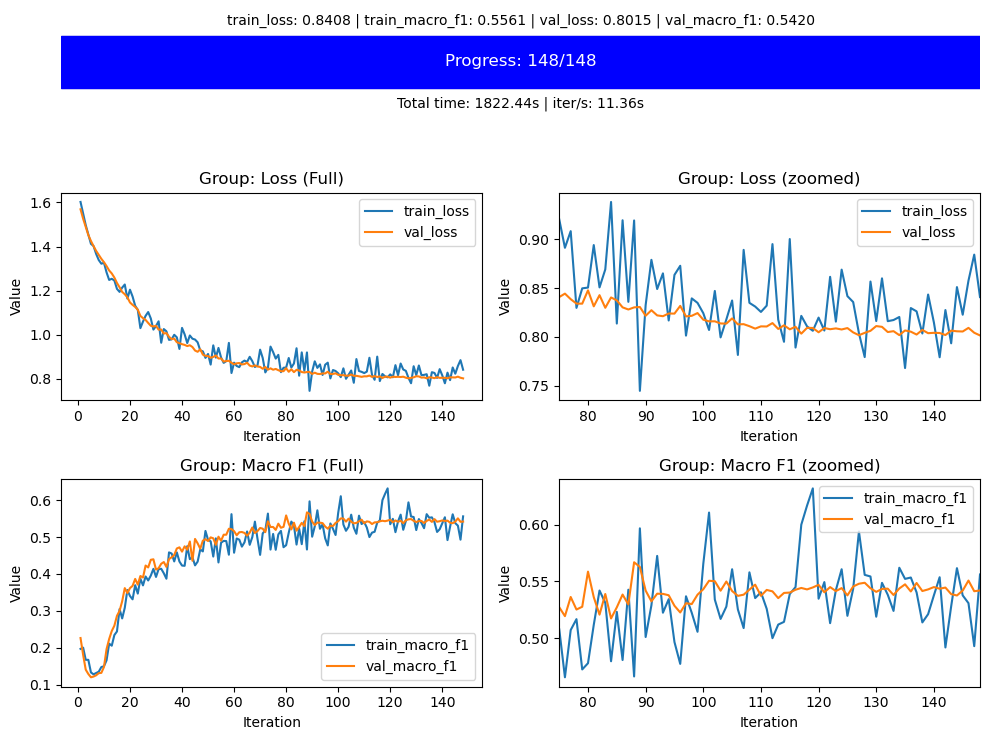

  Epoch 5/5 | Val Loss: 0.8015 | Val F1: 0.5420
Training fertig. Bester Val Macro-F1: 0.5669


In [12]:
model = PigClassifier(num_classes=5).to(device)

learner = Learner(
    model=model,
    train_dl=train_loader,
    val_dl=val_loader,
    eval_steps=20,
)

# Phase 1: Backbone einfrieren, nur Head trainieren
learner.freeze()
best_state, best_f1 = learner.fit(epochs=5, lr=1e-3)



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_per_class(model, dl, class_names, device="cuda:2"):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    for xb, yb in dl:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    print("=" * 60)
    print("Classification Report (pro Klasse)")
    print("=" * 60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

evaluate_per_class(model, val_loader, class_names)

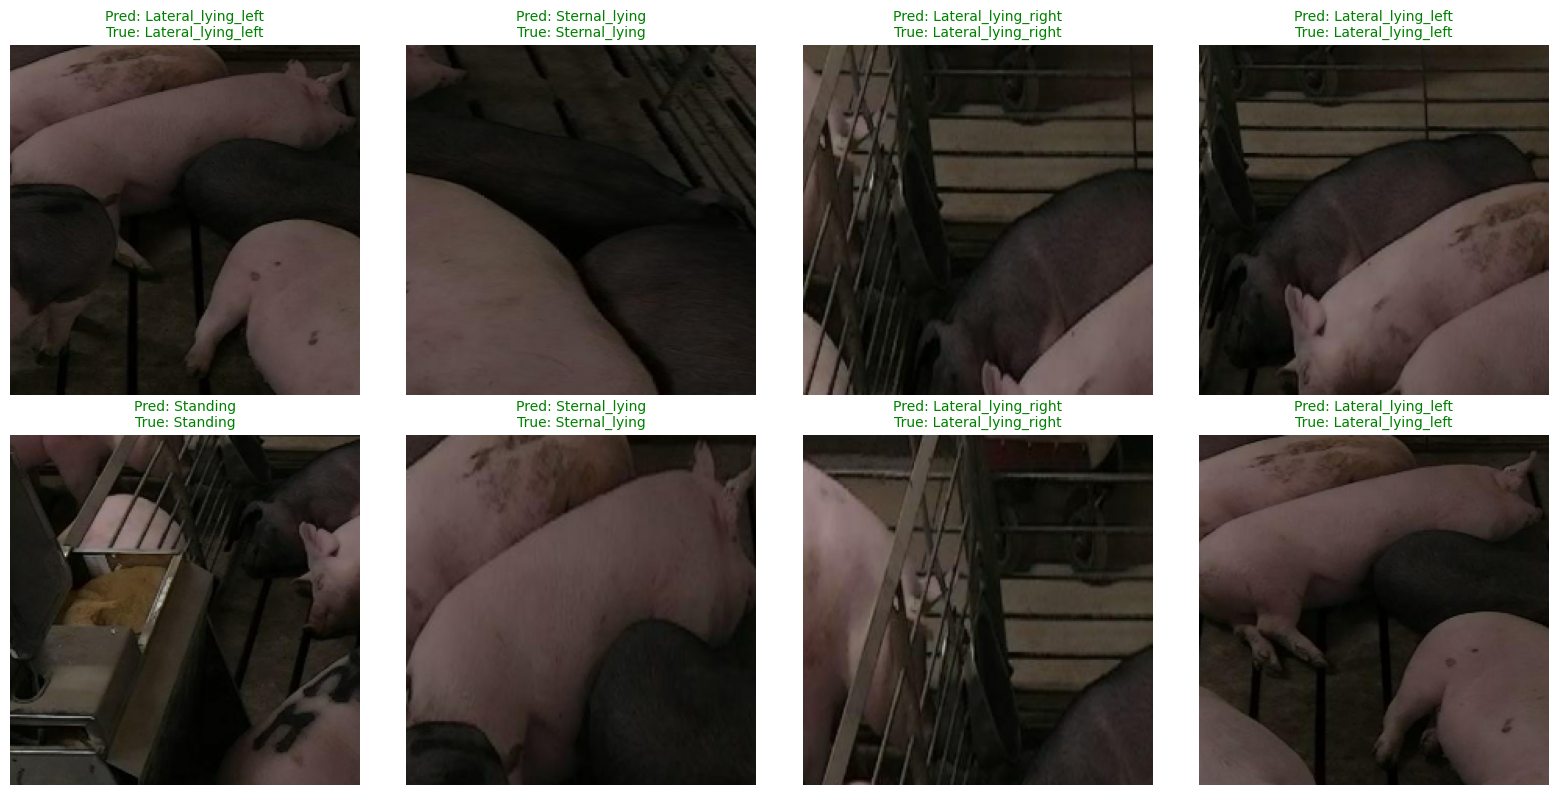

In [13]:
def show_predictions(model, dl, class_names, device="cuda:2", n=8):
    """Zeigt n Bilder mit predicted vs. true Klasse."""
    model.eval()
    model.to(device)

    imgs, labels = next(iter(dl))
    imgs_dev = imgs.to(device)

    with torch.no_grad():
        logits = model(imgs_dev)

    pred_labels = logits.argmax(dim=1).cpu().numpy()
    true_labels = labels.numpy()

    n = min(n, len(imgs))
    cols = max(n // 2, 1)
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 8))
    axes = axes.flatten()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(n):
        img_np = imgs[i].permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        ax = axes[i]
        ax.imshow(img_np)

        pred_name = class_names[pred_labels[i]]
        true_name = class_names[true_labels[i]]
        color = "green" if pred_labels[i] == true_labels[i] else "red"
        ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}", color=color, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

class_names = pig_posture_classes["class_name"].tolist()
show_predictions(model, val_loader, class_names)

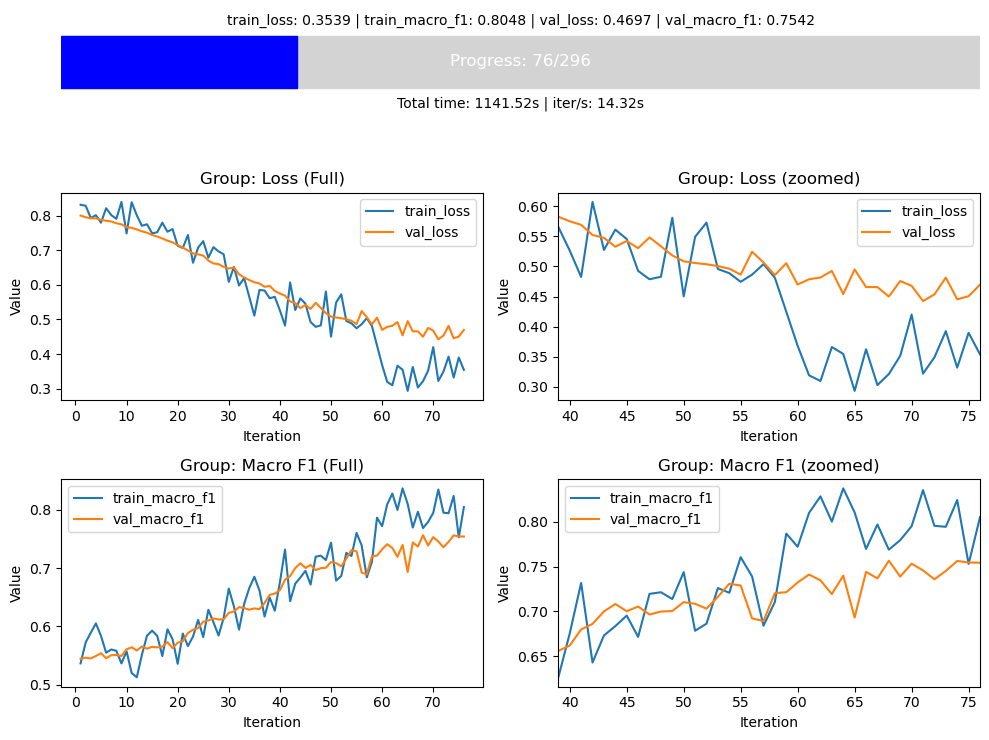

In [ ]:
learner.unfreeze()
best_state, best_f1 = learner.fit(epochs=10, lr=1e-4)

In [ ]:
# Bestes Modell laden und speichern
learner.load_best()
torch.save(model.state_dict(), "pig_classifier_best.pth")

In [ ]:
# ── Speichern falls Notebook abstürzt ──
torch.save(model.state_dict(), "pig_classifier_checkpoint.pth")

In [ ]:
# ── Laden ──
#model = PigClassifier(num_classes=5).to(device)
#model.load_state_dict(torch.load("pig_classifier_checkpoint.pth", map_location=device))

In [ ]:
# Predictions
cls_preds = learner.predict(test_loader)

In [ ]:
# Submission erstellen
submission = pd.DataFrame({
    "row_id":   test_df["row_id"],
    "class_id": cls_preds,
})
submission.head()